### Import TensorFlow

In [1]:
import tensorflow as tf

from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np
from ipywidgets import widgets 
import imageio
from skimage.transform import resize
# Standardize images across the dataset, mean-0, stdev=1
from tensorflow.keras.preprocessing.image import ImageDataGenerator 
import matplotlib.pyplot as plt

### Download and prepare the CIFAR10 dataset


The CIFAR10 dataset contains 60,000 color images in 10 classes, with 6,000 images in each class. The dataset is divided into 50,000 training images and 10,000 testing images. The classes are mutually exclusive and there is no overlap between them.

In [2]:
(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()

# Normalize pixel values to be between 0 and 1
train_images, test_images = train_images / 255.0, test_images / 255.0

### Verify the data

To verify that the dataset looks correct, let's plot the first 25 images from the training set and display the class name below each image:


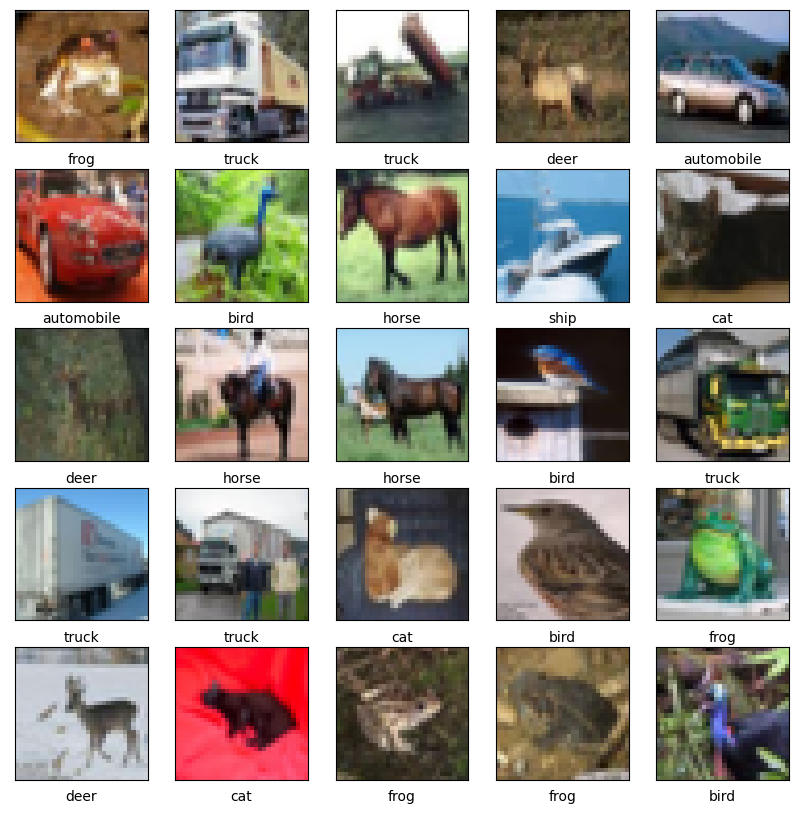

In [3]:
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i])
    # The CIFAR labels happen to be arrays, 
    # which is why you need the extra index
    plt.xlabel(class_names[train_labels[i][0]])
plt.show()

### Create the convolutional base

The 6 lines of code below define the convolutional base using a common pattern: a stack of [Conv2D](https://www.tensorflow.org/api_docs/python/tf/keras/layers/Conv2D) and [MaxPooling2D](https://www.tensorflow.org/api_docs/python/tf/keras/layers/MaxPool2D) layers.

As input, a CNN takes tensors of shape (image_height, image_width, color_channels), ignoring the batch size. If you are new to these dimensions, color_channels refers to (R,G,B). In this example, you will configure your CNN to process inputs of shape (32, 32, 3), which is the format of CIFAR images. You can do this by passing the argument `input_shape` to your first layer.


0.002450057 0.45549506 1.0


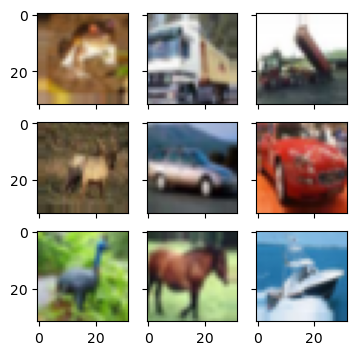

In [4]:
#Data Augmentation 

# load data datagen
datagen = ImageDataGenerator(
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    vertical_flip=False
)

# fit parameters from data
datagen.fit(train_images)

# configure batch size and retrieve one batch of images
for X_batch, y_batch in datagen.flow(train_images, train_labels, batch_size=9, shuffle=False):
    print(X_batch.min(), X_batch.mean(), X_batch.max())

    # create a grid of 3x3 images
    fig, ax = plt.subplots(3, 3, sharex=True, sharey=True, figsize=(4, 4)) 
    for i in range(3):
        for j in range(3):
            ax[i][j].imshow(X_batch[i * 3 + j], cmap=plt.get_cmap("gray"))

    # show the plot
    plt.show()
    break

In [5]:
window_size = (3, 3)
stride = 2

model = models.Sequential()

# First Convolutional Layer
model.add(layers.Conv2D(32, window_size, padding='same', input_shape=(32, 32, 3)))
model.add(layers.LeakyReLU())

# Second Convolutional Layer
model.add(layers.Conv2D(32, window_size))
model.add(layers.LeakyReLU())

# Third Convolutional Layer with Stride
model.add(layers.Conv2D(32, window_size, strides=stride))
model.add(layers.LeakyReLU())

# Fourth Convolutional Layer
model.add(layers.Conv2D(64, window_size))
model.add(layers.LeakyReLU())
model.add(layers.Dropout(0.1))

# Fifth Convolutional Layer
model.add(layers.Conv2D(64, window_size))
model.add(layers.LeakyReLU())
model.add(layers.Dropout(0.1))

# Flatten Layer
model.add(layers.Flatten())

# Dense Layers
model.add(layers.Dense(64))
model.add(layers.LeakyReLU())

# Output Layer
model.add(layers.Dense(10))

Let's display the architecture of your model so far:

In [6]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 32, 32, 32)        896       
                                                                 
 leaky_re_lu (LeakyReLU)     (None, 32, 32, 32)        0         
                                                                 
 conv2d_1 (Conv2D)           (None, 30, 30, 32)        9248      
                                                                 
 leaky_re_lu_1 (LeakyReLU)   (None, 30, 30, 32)        0         
                                                                 
 conv2d_2 (Conv2D)           (None, 14, 14, 32)        9248      
                                                                 
 leaky_re_lu_2 (LeakyReLU)   (None, 14, 14, 32)        0         
                                                                 
 conv2d_3 (Conv2D)           (None, 12, 12, 64)        1

### Compile and train the model

In [7]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

history = model.fit(train_images, train_labels, epochs=10, 
                    validation_data=(test_images, test_labels))

Epoch 1/10
1563/1563 [==============================] - 68s 43ms/step - loss: 1.4280 - accuracy: 0.4882 - val_loss: 1.1677 - val_accuracy: 0.5876
Epoch 2/10
1563/1563 [==============================] - 67s 43ms/step - loss: 1.0396 - accuracy: 0.6348 - val_loss: 1.0084 - val_accuracy: 0.6457
Epoch 3/10
1563/1563 [==============================] - 68s 43ms/step - loss: 0.9014 - accuracy: 0.6825 - val_loss: 1.0033 - val_accuracy: 0.6648
Epoch 4/10
1563/1563 [==============================] - 67s 43ms/step - loss: 0.8148 - accuracy: 0.7151 - val_loss: 0.9184 - val_accuracy: 0.6862
Epoch 5/10
1563/1563 [==============================] - 65s 41ms/step - loss: 0.7414 - accuracy: 0.7417 - val_loss: 0.8970 - val_accuracy: 0.6917
Epoch 6/10
1563/1563 [==============================] - 65s 42ms/step - loss: 0.6876 - accuracy: 0.7595 - val_loss: 0.8439 - val_accuracy: 0.7107
Epoch 7/10
1563/1563 [==============================] - 65s 42ms/step - loss: 0.6399 - accuracy: 0.7756 - val_loss: 0.9011 -

### Evaluate the model

313/313 - 2s - loss: 0.8885 - accuracy: 0.7193 - 2s/epoch - 7ms/step


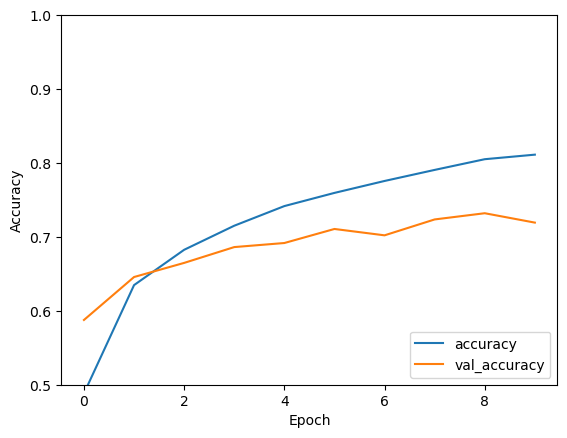

In [8]:
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.5, 1])
plt.legend(loc='lower right')

test_loss, test_acc = model.evaluate(test_images,  test_labels, verbose=2)

In [9]:
print(test_acc)

0.7192999720573425


In [11]:
model.save('cifar10-cnn-10.1')

INFO:tensorflow:Assets written to: cifar10-cnn-10.1\assets


INFO:tensorflow:Assets written to: cifar10-cnn-10.1\assets


In [12]:
model = tf.keras.models.load_model('cifar10-cnn-10.1')

1/1 [==============================] - 0s 83ms/step
predicting:  frog
answer is: frog


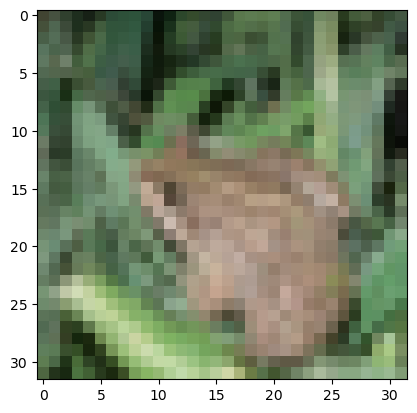

In [13]:
#import numpy as np
index = 4
plt.imshow(test_images [index])
test = np.expand_dims (test_images[index], axis=0)
pred =  model.predict(test)
lbl = test_labels [index]

idx = pred.argmax() #predictions one-hot encoded 
print("predicting: ", class_names[idx])
print("answer is:", class_names[lbl[0]]) #label is single number